# NBAIoT — ML Classification (Universal)

**Dataset:** [N-BaIoT on Kaggle](https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset)  
**Задача 1:** Бинарная классификация — benign vs malicious  
**Задача 2:** Мультиклассовая — определение типа атаки  

---
### Как настроить ноутбук
Все параметры — в ячейке **«Конфигурация»**:
| Параметр | Что меняет |
|---|---|
| `SAMPLE_FRACTION` | Доля датасета (0.0–1.0). `0.1` = 10%, `1.0` = весь датасет |
| `TEST_SIZE` | Доля тестовой выборки от отобранного объёма |
| `N_PCA_COMPONENTS` | Кол-во PCA-компонент (17 → 95% дисперсии) |
| `MODELS` | Словарь алгоритмов — добавляйте/удаляйте без изменения остального кода |

## 0. Конфигурация железа

In [1]:
import platform, subprocess
import psutil

print("=" * 62)
print("  КОНФИГУРАЦИЯ СИСТЕМЫ")
print("=" * 62)
print(f"ОС                : {platform.system()} {platform.release()}")
print(f"Версия ОС         : {platform.version()}")
print(f"Архитектура       : {platform.machine()}")
print(f"Процессор         : {platform.processor()}")
print(f"Python            : {platform.python_version()}")

print(f"Ядра CPU (физ.)   : {psutil.cpu_count(logical=False)}")
print(f"Ядра CPU (лог.)   : {psutil.cpu_count(logical=True)}")
try:
    freq = psutil.cpu_freq()
    print(f"Частота CPU макс. : {freq.max:.0f} МГц")
except Exception:
    pass

ram = psutil.virtual_memory()
print(f"RAM всего         : {ram.total / 1024**3:.2f} ГБ")
print(f"RAM доступно      : {ram.available / 1024**3:.2f} ГБ")

print()
try:
    gpu_info = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
         "--format=csv,noheader"], stderr=subprocess.DEVNULL
    ).decode().strip()
    print(f"GPU               : {gpu_info}")
    print("Примечание        : XGBoost работает на CPU (device='cpu')")
except Exception:
    print("GPU               : не обнаружен")
    print("Примечание        : XGBoost работает на CPU")

print()
print("=" * 62)
print("  ВЕРСИИ БИБЛИОТЕК")
print("=" * 62)
import sklearn, xgboost, numpy as np, pandas as pd
print(f"scikit-learn      : {sklearn.__version__}")
print(f"xgboost           : {xgboost.__version__}")
print(f"numpy             : {np.__version__}")
print(f"pandas            : {pd.__version__}")

  КОНФИГУРАЦИЯ СИСТЕМЫ
ОС                : Linux 5.4.0-216-generic
Версия ОС         : #236-Ubuntu SMP Fri Apr 11 19:53:21 UTC 2025
Архитектура       : x86_64
Процессор         : x86_64
Python            : 3.10.12
Ядра CPU (физ.)   : 4
Ядра CPU (лог.)   : 8
Частота CPU макс. : 0 МГц
RAM всего         : 62.80 ГБ
RAM доступно      : 60.92 ГБ

GPU               : не обнаружен
Примечание        : XGBoost работает на CPU

  ВЕРСИИ БИБЛИОТЕК
scikit-learn      : 1.2.2
xgboost           : 1.7.6
numpy             : 1.22.4
pandas            : 1.5.3


## 1. Импорты и конфигурация

In [2]:
import time, warnings, gc, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ╔══════════════════════════════════════════════════════════════╗
# ║                  ГЛОБАЛЬНЫЕ ПАРАМЕТРЫ                       ║
# ╚══════════════════════════════════════════════════════════════╝

# Путь к директории с CSV-файлами датасета
DATA_DIR = Path("../datasets")

# Доля датасета, задействованная в обучении и тестах
# Диапазон: (0.0, 1.0]. 1.0 = весь датасет, 0.1 = 10% и т.д.
SAMPLE_FRACTION = 0.2

# Доля тестовой выборки от отобранных данных
TEST_SIZE = 0.20

# Кол-во PCA-компонент (из разведочного анализа: 17 → 95% дисперсии)
N_PCA_COMPONENTS = 17

RANDOM_STATE = 42
METRICS      = ["accuracy", "precision", "recall"]

sns.set_theme(style="whitegrid", palette="muted")
print(f"Конфигурация загружена.")
print(f"  SAMPLE_FRACTION  = {SAMPLE_FRACTION} ({SAMPLE_FRACTION*100:.0f}% датасета)")
print(f"  TEST_SIZE        = {TEST_SIZE}")
print(f"  N_PCA_COMPONENTS = {N_PCA_COMPONENTS}")
print(f"  RANDOM_STATE     = {RANDOM_STATE}")

Конфигурация загружена.
  SAMPLE_FRACTION  = 0.2 (20% датасета)
  TEST_SIZE        = 0.2
  N_PCA_COMPONENTS = 17
  RANDOM_STATE     = 42


## 2. Загрузка данных

In [3]:
BENIGN_KEYWORDS = ["benign"]

csv_files = sorted(DATA_DIR.rglob("*.csv"))
assert len(csv_files) > 0, f"CSV-файлы не найдены в {DATA_DIR}!"
print(f"Найдено CSV-файлов: {len(csv_files)}")

frames = []
for fpath in csv_files:
    df_tmp = pd.read_csv(fpath)
    stem   = fpath.stem.lower()
    parent = fpath.parent.name.lower()

    is_benign   = any(kw in stem or kw in parent for kw in BENIGN_KEYWORDS)
    clean_stem  = stem.lstrip("0123456789.").strip().replace(" ", "_")
    label_multi = "benign" if is_benign else (clean_stem or parent)

    df_tmp["label_multi"]  = label_multi
    df_tmp["label_binary"] = 0 if is_benign else 1

    frames.append(df_tmp)
    print(f"  {len(df_tmp):>8,} строк  label='{label_multi}'  [{fpath.name}]")

df = pd.concat(frames, ignore_index=True)
print(f"\nИтого загружено: {df.shape[0]:,} строк × {df.shape[1]} колонок")
del frames; gc.collect()

Найдено CSV-файлов: 89
    49,548 строк  label='benign'  [1.benign.csv]
    59,718 строк  label='gafgyt.combo'  [1.gafgyt.combo.csv]
    29,068 строк  label='gafgyt.junk'  [1.gafgyt.junk.csv]
    29,849 строк  label='gafgyt.scan'  [1.gafgyt.scan.csv]
    92,141 строк  label='gafgyt.tcp'  [1.gafgyt.tcp.csv]
   105,874 строк  label='gafgyt.udp'  [1.gafgyt.udp.csv]
   102,195 строк  label='mirai.ack'  [1.mirai.ack.csv]
   107,685 строк  label='mirai.scan'  [1.mirai.scan.csv]
   122,573 строк  label='mirai.syn'  [1.mirai.syn.csv]
   237,665 строк  label='mirai.udp'  [1.mirai.udp.csv]
    81,982 строк  label='mirai.udpplain'  [1.mirai.udpplain.csv]
    13,113 строк  label='benign'  [2.benign.csv]
    53,012 строк  label='gafgyt.combo'  [2.gafgyt.combo.csv]
    30,312 строк  label='gafgyt.junk'  [2.gafgyt.junk.csv]
    27,494 строк  label='gafgyt.scan'  [2.gafgyt.scan.csv]
    95,021 строк  label='gafgyt.tcp'  [2.gafgyt.tcp.csv]
   104,791 строк  label='gafgyt.udp'  [2.gafgyt.udp.csv]
   113

48

## 3. Выборка данных

Управляется параметром `SAMPLE_FRACTION`.  
Используется стратифицированная выборка — сохраняет распределение классов.

In [4]:
total_rows = len(df)

if SAMPLE_FRACTION < 1.0:
    assert 0.0 < SAMPLE_FRACTION < 1.0, "SAMPLE_FRACTION должен быть в диапазоне (0, 1]"

    df, _ = train_test_split(
        df,
        train_size=SAMPLE_FRACTION,
        random_state=RANDOM_STATE,
        stratify=df["label_binary"]   # стратификация по бинарной метке
    )
    df = df.reset_index(drop=True)
    print(f"Стратифицированная выборка: {SAMPLE_FRACTION*100:.0f}% от датасета")
else:
    print("Используется весь датасет (SAMPLE_FRACTION = 1.0)")

sampled_rows = len(df)
print(f"  Всего строк     : {total_rows:>12,}")
print(f"  После выборки   : {sampled_rows:>12,}  ({sampled_rows/total_rows*100:.1f}%)")

# Распределение бинарных классов после выборки
print("\nРаспределение классов (бинарная):")
print(df["label_binary"].value_counts().rename({0: "benign", 1: "malicious"}).to_string())

Стратифицированная выборка: 20% от датасета
  Всего строк     :    7,062,606
  После выборки   :    1,412,521  (20.0%)

Распределение классов (бинарная):
malicious    1301335
benign        111186


## 4. Предобработка

In [5]:
FEATURE_COLS = [c for c in df.columns if c not in ("label_binary", "label_multi")]

# Дедупликация
before_dedup = len(df)
df = df.drop_duplicates(subset=FEATURE_COLS).reset_index(drop=True)
print(f"Дедупликация: {before_dedup:,} → {len(df):,} строк (-{before_dedup - len(df):,})")

# Удаление константных признаков
std_vals    = df[FEATURE_COLS].std()
const_feats = std_vals[std_vals == 0].index.tolist()
if const_feats:
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in const_feats]
    print(f"Удалено константных признаков: {len(const_feats)}")
print(f"Признаков для обучения: {len(FEATURE_COLS)}")

# Заполнение пропусков
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)

# Метки
y_bin   = df["label_binary"].values
y_multi = df["label_multi"].values

le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)
n_classes   = len(le.classes_)

# Параметр дисбаланса для XGBoost
bin_counts       = pd.Series(y_bin).value_counts()
imbalance_ratio  = bin_counts.max() / bin_counts.min()
scale_pos_weight = int(bin_counts[0]) / int(bin_counts[1])

print(f"\nКлассы мультиклассовой задачи ({n_classes}): {list(le.classes_)}")
print(f"Дисбаланс бинарных классов: {imbalance_ratio:.1f}:1")
print(f"  scale_pos_weight (XGBoost binary) = {scale_pos_weight:.2f}")

Дедупликация: 1,412,521 → 1,017,849 строк (-394,672)
Признаков для обучения: 115

Классы мультиклассовой задачи (11): ['benign', 'gafgyt.combo', 'gafgyt.junk', 'gafgyt.scan', 'gafgyt.tcp', 'gafgyt.udp', 'mirai.ack', 'mirai.scan', 'mirai.syn', 'mirai.udp', 'mirai.udpplain']
Дисбаланс бинарных классов: 8.4:1
  scale_pos_weight (XGBoost binary) = 0.12


## 5. Масштабирование и PCA

In [6]:
X_raw = df[FEATURE_COLS].values.astype(np.float32)

# RobustScaler — устойчив к выбросам; используется как вход для всех моделей
robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X_raw).astype(np.float32)

# StandardScaler + PCA
# StandardScaler нужен перед PCA, чтобы признаки с большим разбросом
# не доминировали в главных компонентах
std_scaler = StandardScaler()
X_std      = std_scaler.fit_transform(X_raw).astype(np.float64)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_std).astype(np.float32)

explained = pca.explained_variance_ratio_.sum()
print(f"RobustScaler → {X_robust.shape}")
print(f"PCA: {X_raw.shape[1]} признаков → {N_PCA_COMPONENTS} компонент "
      f"(объясн. дисперсия: {explained*100:.1f}%)")
del X_std; gc.collect()

RobustScaler → (1017849, 115)
PCA: 115 признаков → 17 компонент (объясн. дисперсия: 95.1%)


72

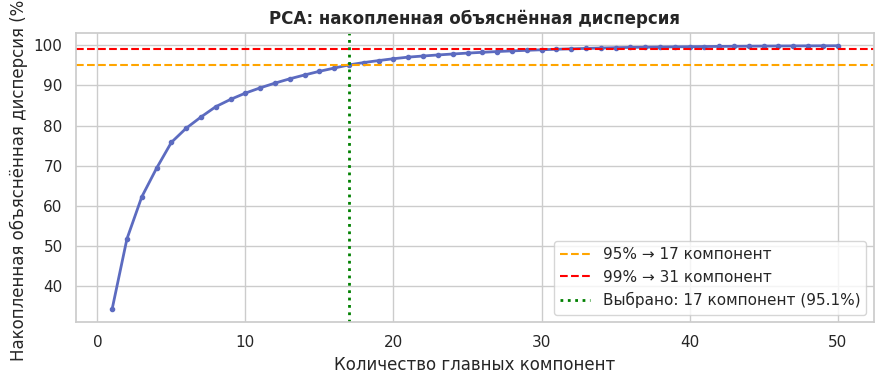

In [7]:
# График объяснённой дисперсии PCA
pca_plot = PCA(n_components=min(50, len(FEATURE_COLS)), random_state=RANDOM_STATE)
sample_idx  = np.random.default_rng(RANDOM_STATE).choice(
    len(X_raw), size=min(100_000, len(X_raw)), replace=False
)
X_std_s = StandardScaler().fit_transform(X_raw[sample_idx]).astype(np.float64)
pca_plot.fit(X_std_s)
del X_std_s; gc.collect()

cumvar = np.cumsum(pca_plot.explained_variance_ratio_)
n95    = int(np.argmax(cumvar >= 0.95)) + 1
n99    = int(np.argmax(cumvar >= 0.99)) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, marker='.', color='#5C6BC0', lw=2)
ax.axhline(95, color='orange', ls='--', label=f'95% → {n95} компонент')
ax.axhline(99, color='red',    ls='--', label=f'99% → {n99} компонент')
ax.axvline(N_PCA_COMPONENTS, color='green', ls=':', lw=2,
           label=f'Выбрано: {N_PCA_COMPONENTS} компонент ({explained*100:.1f}%)')
ax.set_xlabel('Количество главных компонент')
ax.set_ylabel('Накопленная объяснённая дисперсия (%)')
ax.set_title('PCA: накопленная объяснённая дисперсия', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=120)
plt.show()

## 6. Разбивка на train / test

Формируем **4 пары** (binary/multi × full/pca).  
Все последующие шаги работают с этими готовыми массивами.

In [8]:
# Стратифицированное разбиение по бинарной метке для обеих задач
split_kw_b = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin)
split_kw_m = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_multi_enc)

# Full features
Xr_tr_b, Xr_te_b, y_tr_b, y_te_b = train_test_split(X_robust, y_bin,        **split_kw_b)
Xr_tr_m, Xr_te_m, y_tr_m, y_te_m = train_test_split(X_robust, y_multi_enc,  **split_kw_m)

# PCA features
Xp_tr_b, Xp_te_b, _,      _      = train_test_split(X_pca,    y_bin,        **split_kw_b)
Xp_tr_m, Xp_te_m, _,      _      = train_test_split(X_pca,    y_multi_enc,  **split_kw_m)

# Словарь наборов данных для удобного перебора в цикле
DATASETS = {
    "full": {
        "binary":      (Xr_tr_b, Xr_te_b, y_tr_b, y_te_b),
        "multiclass":  (Xr_tr_m, Xr_te_m, y_tr_m, y_te_m),
    },
    f"pca-{N_PCA_COMPONENTS}": {
        "binary":      (Xp_tr_b, Xp_te_b, y_tr_b, y_te_b),
        "multiclass":  (Xp_tr_m, Xp_te_m, y_tr_m, y_te_m),
    },
}

used_pct = SAMPLE_FRACTION * 100
print(f"Данные ({used_pct:.0f}% датасета):")
print(f"  Train: {len(Xr_tr_b):,} строк  ({(1-TEST_SIZE)*used_pct:.0f}% от исходного)")
print(f"  Test : {len(Xr_te_b):,} строк  ({TEST_SIZE*used_pct:.0f}% от исходного)")
print(f"\nНаборы данных:")
for fmode, tasks in DATASETS.items():
    for task, (Xtr, Xte, ytr, yte) in tasks.items():
        print(f"  [{fmode}][{task}]  X_train={Xtr.shape}  X_test={Xte.shape}")

Данные (20% датасета):
  Train: 814,279 строк  (16% от исходного)
  Test : 203,570 строк  (4% от исходного)

Наборы данных:
  [full][binary]  X_train=(814279, 115)  X_test=(203570, 115)
  [full][multiclass]  X_train=(814279, 115)  X_test=(203570, 115)
  [pca-17][binary]  X_train=(814279, 17)  X_test=(203570, 17)
  [pca-17][multiclass]  X_train=(814279, 17)  X_test=(203570, 17)


## 7. Реестр алгоритмов

**Чтобы добавить новый алгоритм** — добавьте запись в словарь `MODELS`.  
**Чтобы убрать** — удалите запись или закомментируйте.  
Весь остальной код (обучение, метрики, графики) не меняется.

In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              РЕЕСТР АЛГОРИТМОВ (редактировать здесь)        ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  Формат: {"Название": {"binary": <model>, "multiclass": <model>}}  ║
# ║  Для бинарной и мультиклассовой могут быть разные гиперпарам║
# ╚══════════════════════════════════════════════════════════════╝

MODELS = {

    "Decision Tree": {
        "binary": DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=5,
            class_weight="balanced",   # компенсация дисбаланса
            random_state=RANDOM_STATE
        ),
        "multiclass": DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
    },

    "Random Forest": {
        "binary": RandomForestClassifier(
            n_estimators=100,
            max_depth=6,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
        "multiclass": RandomForestClassifier(
            n_estimators=100,
            max_depth=6,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
    },

    "XGBoost (CPU)": {
        "binary": XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,  # компенсация дисбаланса
            tree_method="hist",
            device="cpu",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            verbosity=0
        ),
        "multiclass": XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softmax",
            num_class=n_classes,
            tree_method="hist",
            device="cpu",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            verbosity=0
        ),
    },

    # ── Чтобы добавить алгоритм, вставьте блок ниже: ──────────
    # "My Algorithm": {
    #     "binary":     MyClassifier(...),
    #     "multiclass": MyClassifier(...),
    # },

}

print(f"Алгоритмов в реестре: {len(MODELS)}")
for name in MODELS:
    print(f"  • {name}")

Алгоритмов в реестре: 3
  • Decision Tree
  • Random Forest
  • XGBoost (CPU)


## 8. Вспомогательные функции

In [18]:
# ──────────────────────────────────────────────────────────────────────────
# Обучение и оценка одной модели
# ──────────────────────────────────────────────────────────────────────────

def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       task="binary", class_names=None,
                       algo_name="", feature_mode=""):
    """
    Обучает модель и возвращает словарь с метриками и предсказаниями.
    Использует clone() — исходный объект модели не изменяется.
    """
    avg     = "binary" if task == "binary" else "weighted"
    m       = clone(model)              # свежая копия, без предыдущих весов

    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    y_pred   = m.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=avg, zero_division=0)
    recall    = recall_score(y_test, y_pred, average=avg, zero_division=0)

    avg_tag = "" if task == "binary" else " (weighted)"
    print(f"  [{feature_mode}] {algo_name} / {task}")
    print(f"    Время обучения : {train_time:.2f}с")
    print(f"    Accuracy       : {accuracy:.4f}")
    print(f"    Precision      : {precision:.4f}{avg_tag}")
    print(f"    Recall         : {recall:.4f}{avg_tag}")

    if class_names is not None and task != "binary":
        print()
        print(classification_report(
            y_test, y_pred, target_names=class_names, zero_division=0
        ))

    return {
        "model":      m,
        "y_pred":     y_pred,
        "accuracy":   accuracy,
        "precision":  precision,
        "recall":     recall,
        "train_time": train_time,
    }


# ──────────────────────────────────────────────────────────────────────────
# Построение сводной таблицы
# ──────────────────────────────────────────────────────────────────────────

def build_summary(all_results, task):
    """
    Строит DataFrame с метриками по всем алгоритмам и режимам признаков.
    all_results: {algo_name: {feature_mode: {task: result_dict}}}
    """
    rows = []
    for algo_name, modes in all_results.items():
        for feature_mode, tasks in modes.items():
            res = tasks[task]
            rows.append({
                "Алгоритм":       algo_name,
                "Признаки":       feature_mode,
                "Accuracy":       res["accuracy"],
                "Precision":      res["precision"],
                "Recall":         res["recall"],
                "Train time (s)": res["train_time"],
            })
    return pd.DataFrame(rows)


# ──────────────────────────────────────────────────────────────────────────
# Матрица ошибок
# ──────────────────────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm  = confusion_matrix(y_true, y_pred)
    sz  = max(6, len(class_names))
    fig, ax = plt.subplots(figsize=(sz, sz - 1))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, colorbar=True, cmap="Blues", xticks_rotation="vertical"
    )
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Универсальный bar-chart сравнения метрик
# ──────────────────────────────────────────────────────────────────────────

def plot_metrics_comparison(df_summary, task_label):
    """
    Строит сгруппированный bar-chart для всех алгоритмов из df_summary.
    Работает для любого кол-ва алгоритмов и режимов признаков.
    """
    # Создаём составной ключ «Алгоритм / Признаки» для оси X
    df_plot = df_summary.copy()
    df_plot["label"] = df_plot["Алгоритм"] + "\n" + df_plot["Признаки"]

    n_groups  = len(df_plot)
    n_metrics = len(METRICS)
    x         = np.arange(n_groups)
    width     = 0.22
    colors    = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 1.5), 5))
    for i, metric in enumerate(METRICS):
        vals = df_plot[metric.capitalize()].values
        bars = ax.bar(
            x + i * width, vals, width,
            label=metric.capitalize(),
            color=colors[i % len(colors)],
            edgecolor="k", linewidth=0.5
        )
        for b in bars:
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + 0.005,
                f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=7
            )

    ax.set_xticks(x + width * (n_metrics - 1) / 2)
    ax.set_xticklabels(df_plot["label"], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"{task_label} — сравнение метрик", fontweight="bold")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Сравнение времени обучения
# ──────────────────────────────────────────────────────────────────────────

def plot_train_time_comparison(df_summary, task_label):
    """
    Pivot-bar: алгоритм vs режим признаков (full / pca).
    Работает для любого кол-ва алгоритмов.
    """
    pivot = df_summary.pivot(index="Алгоритм", columns="Признаки", values="Train time (s)")
    ax    = pivot.plot(kind="bar", figsize=(max(8, len(pivot) * 2), 4),
                       edgecolor="k", linewidth=0.5)
    ax.set_title(f"{task_label} — время обучения", fontweight="bold")
    ax.set_ylabel("Секунды")
    ax.set_xlabel("")
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Важность признаков
# ──────────────────────────────────────────────────────────────────────────

def plot_feature_importance(model, feature_names, title, top_n=20):
    """
    Строит bar-chart важности признаков, если модель поддерживает feature_importances_.
    """
    if not hasattr(model, "feature_importances_"):
        print(f"  Пропущено: {title!r} не поддерживает feature_importances_")
        return

    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(indices)), importances[indices], color="steelblue", edgecolor="k")
    ax.set_xticks(range(len(indices)))
    ax.set_xticklabels(
        [feature_names[i] for i in indices],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_title(f"Топ-{top_n} важных признаков — {title}", fontweight="bold")
    ax.set_ylabel("Важность")
    plt.tight_layout()
    plt.show()


print("Все вспомогательные функции определены.")

Все вспомогательные функции определены.


## 9. Универсальный цикл обучения

Этот блок **не нужно менять** при добавлении/удалении алгоритмов.  
Результаты сохраняются в `all_results`:  
```
all_results[algo_name][feature_mode][task] → dict(accuracy, precision, recall, ...)
```

In [11]:
# Метки классов для матриц ошибок
CLASS_NAMES = {
    "binary":     ["Benign", "Malicious"],
    "multiclass": le.classes_,
}

# Структура для хранения всех результатов
# {algo_name: {feature_mode: {task: result_dict}}}
all_results = {}

# ── Внешний цикл: алгоритм ────────────────────────────────────────────────
for algo_name, algo_models in MODELS.items():

    print(f"\n{'='*62}")
    print(f"  АЛГОРИТМ: {algo_name}")
    print(f"{'='*62}")

    all_results[algo_name] = {}

    # ── Средний цикл: режим признаков (full / pca) ────────────────────────
    for feature_mode, task_datasets in DATASETS.items():

        all_results[algo_name][feature_mode] = {}

        # ── Внутренний цикл: задача (binary / multiclass) ─────────────────
        for task, (X_tr, X_te, y_tr, y_te) in task_datasets.items():

            result = train_and_evaluate(
                model        = algo_models[task],
                X_train      = X_tr,
                y_train      = y_tr,
                X_test       = X_te,
                y_test       = y_te,
                task         = task,
                class_names  = CLASS_NAMES[task] if task == "multiclass" else None,
                algo_name    = algo_name,
                feature_mode = feature_mode,
            )
            all_results[algo_name][feature_mode][task] = result

print("\n✓ Обучение завершено.")


  АЛГОРИТМ: Decision Tree
  [full] Decision Tree / binary
    Время обучения : 57.90с
    Accuracy       : 0.9986
    Precision      : 0.9986
    Recall         : 0.9998
  [full] Decision Tree / multiclass
    Время обучения : 55.40с
    Accuracy       : 0.8168
    Precision      : 0.8582 (weighted)
    Recall         : 0.8168 (weighted)

                precision    recall  f1-score   support

        benign       1.00      1.00      1.00     21715
  gafgyt.combo       1.00      0.52      0.68     10221
   gafgyt.junk       0.51      1.00      0.68      5184
   gafgyt.scan       1.00      1.00      1.00      5066
    gafgyt.tcp       0.47      1.00      0.64     16041
    gafgyt.udp       0.61      0.00      0.00     17828
     mirai.ack       1.00      0.67      0.81     22186
    mirai.scan       1.00      1.00      1.00     19003
     mirai.syn       1.00      1.00      1.00     25320
     mirai.udp       0.75      1.00      0.86     42951
mirai.udpplain       1.00      0.60      

## 10. Сводные таблицы метрик

In [12]:
df_binary    = build_summary(all_results, "binary")
df_multiclass = build_summary(all_results, "multiclass")

fmt = "{:.4f}".format

print("\n── БИНАРНАЯ КЛАССИФИКАЦИЯ ─────────────────────────────────")
print(df_binary.to_string(index=False, float_format=fmt))

print("\n── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ──────────────────────────")
print(df_multiclass.to_string(index=False, float_format=fmt))

# Лучшие модели
best_bin   = df_binary.loc[df_binary["Accuracy"].idxmax()]
best_multi = df_multiclass.loc[df_multiclass["Accuracy"].idxmax()]

print(f"\n★  Лучшая бинарная модель    : {best_bin['Алгоритм']} [{best_bin['Признаки']}]  "
      f"Accuracy={best_bin['Accuracy']:.4f}")
print(f"★  Лучшая мультиклас. модель : {best_multi['Алгоритм']} [{best_multi['Признаки']}]  "
      f"Accuracy={best_multi['Accuracy']:.4f}")


── БИНАРНАЯ КЛАССИФИКАЦИЯ ─────────────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9986     0.9986  0.9998         57.8976
Decision Tree   pca-17    0.9986     1.0000  0.9984         17.2699
Random Forest     full    0.9998     1.0000  0.9997         48.2660
Random Forest   pca-17    0.9991     0.9999  0.9991         51.2424
XGBoost (CPU)     full    1.0000     1.0000  0.9999          7.6774
XGBoost (CPU)   pca-17    0.9996     1.0000  0.9995          2.2578

── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ──────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.8168     0.8582  0.8168         55.3977
Decision Tree   pca-17    0.7293     0.8637  0.7293         17.6817
Random Forest     full    0.9025     0.8624  0.9025         63.6489
Random Forest   pca-17    0.8274     0.8608  0.8274         52.2544
XGBoost (CPU)     full    0.9969     0.9970  0.9969         66

## 11. Графики метрик

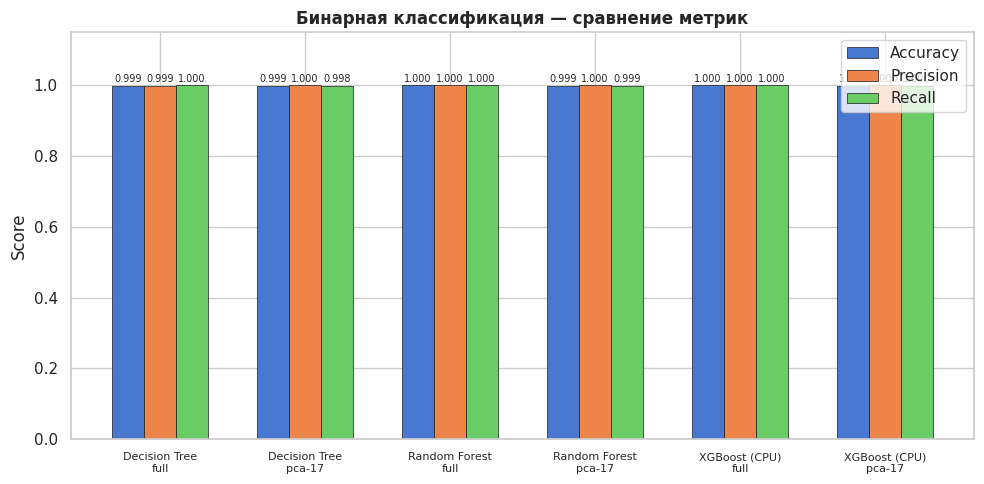

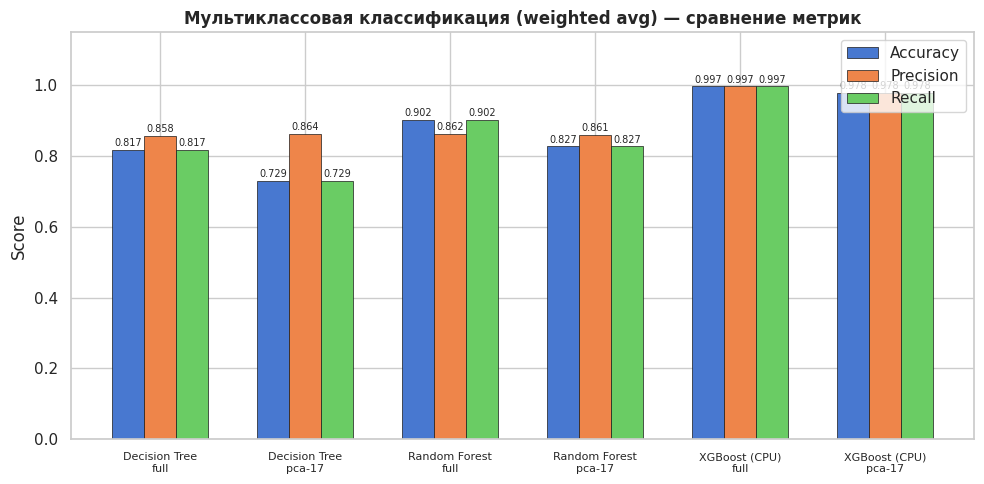

In [19]:
plot_metrics_comparison(
    df_binary,
    task_label="Бинарная классификация"
)

plot_metrics_comparison(
    df_multiclass,
    task_label="Мультиклассовая классификация (weighted avg)"
)

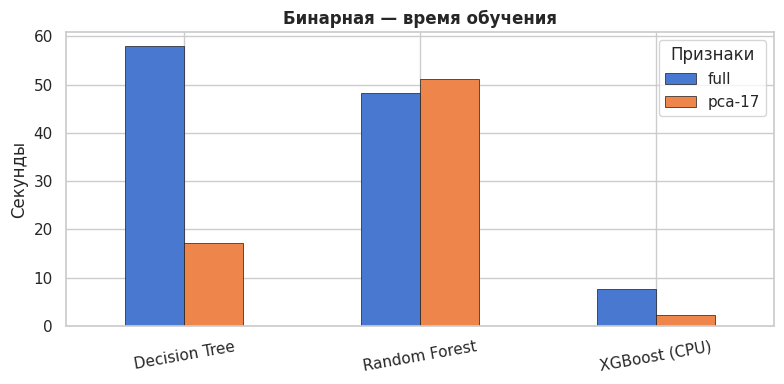

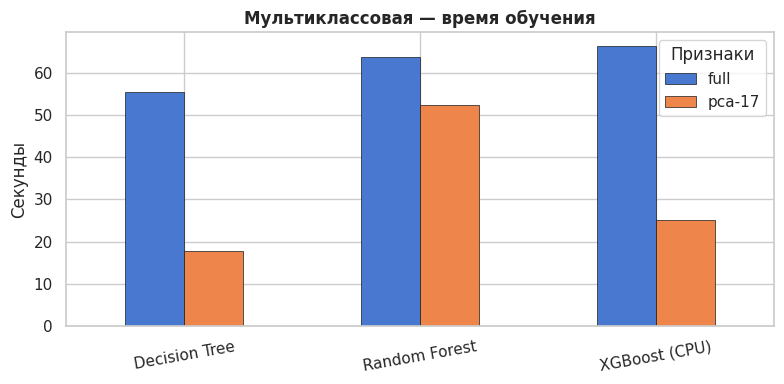

In [20]:
plot_train_time_comparison(
    df_binary,
    task_label="Бинарная"
)

plot_train_time_comparison(
    df_multiclass,
    task_label="Мультиклассовая"
)

## 12. Матрицы ошибок

Генерируются **автоматически** для каждого алгоритма × каждого режима признаков.

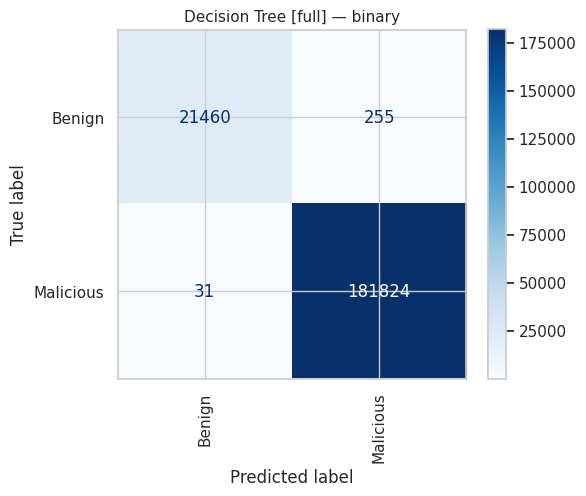

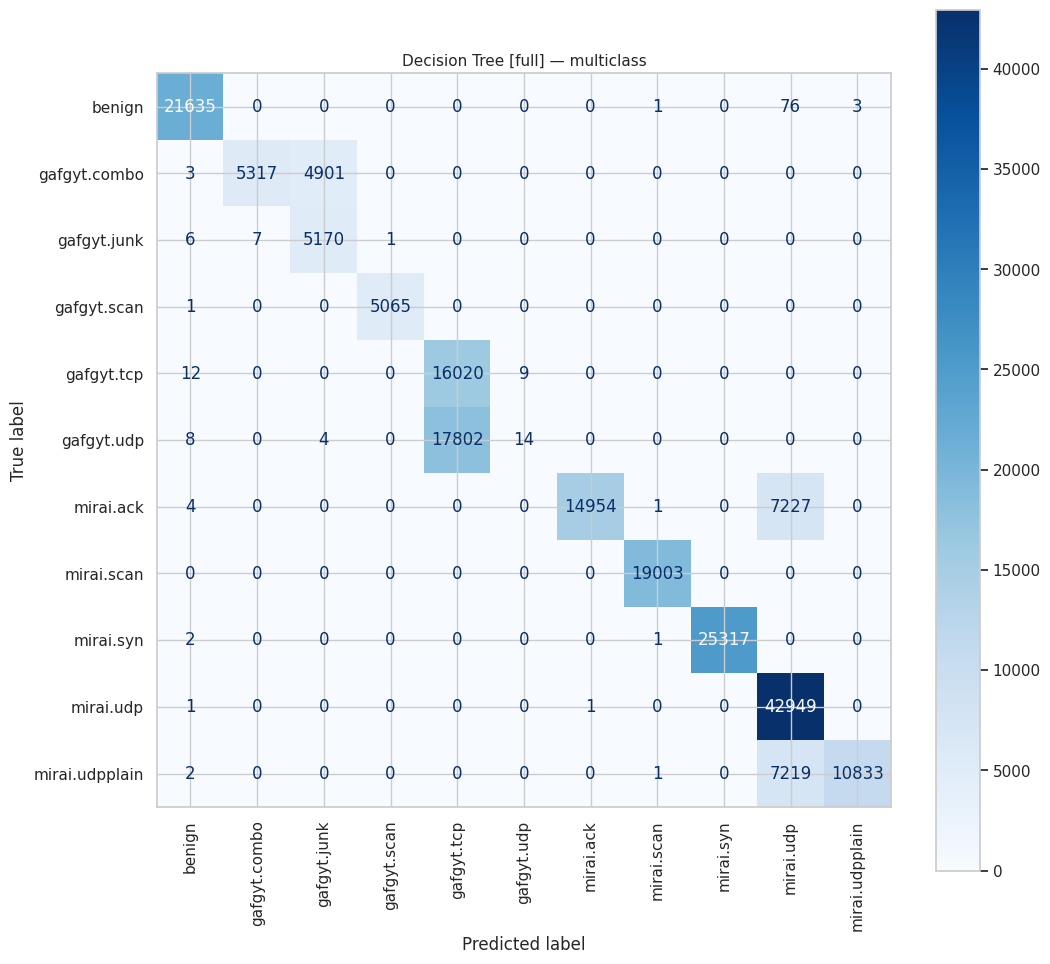

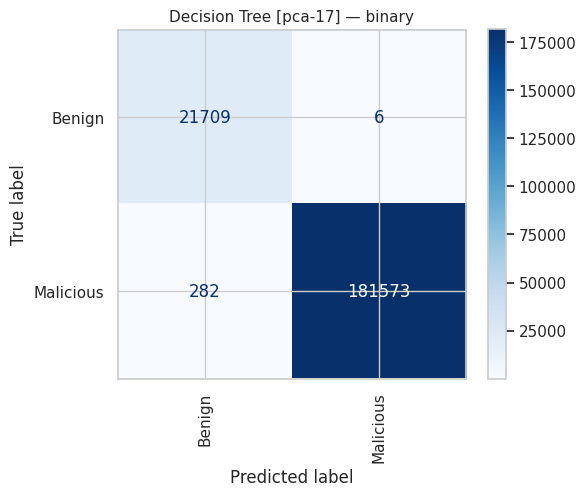

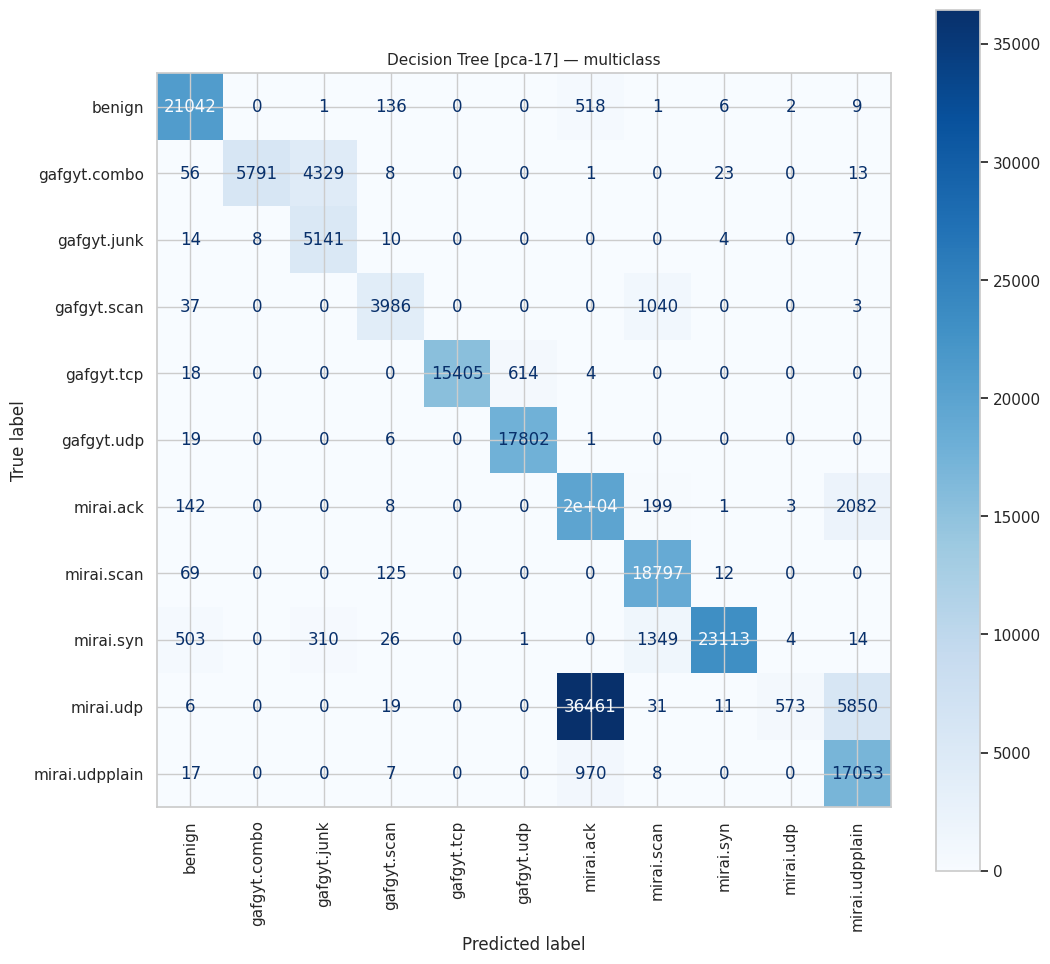

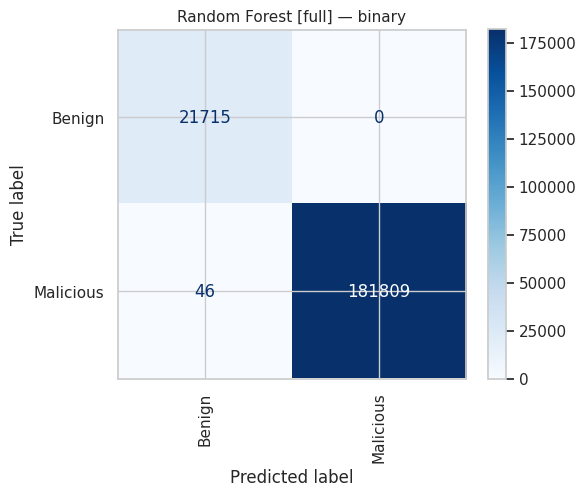

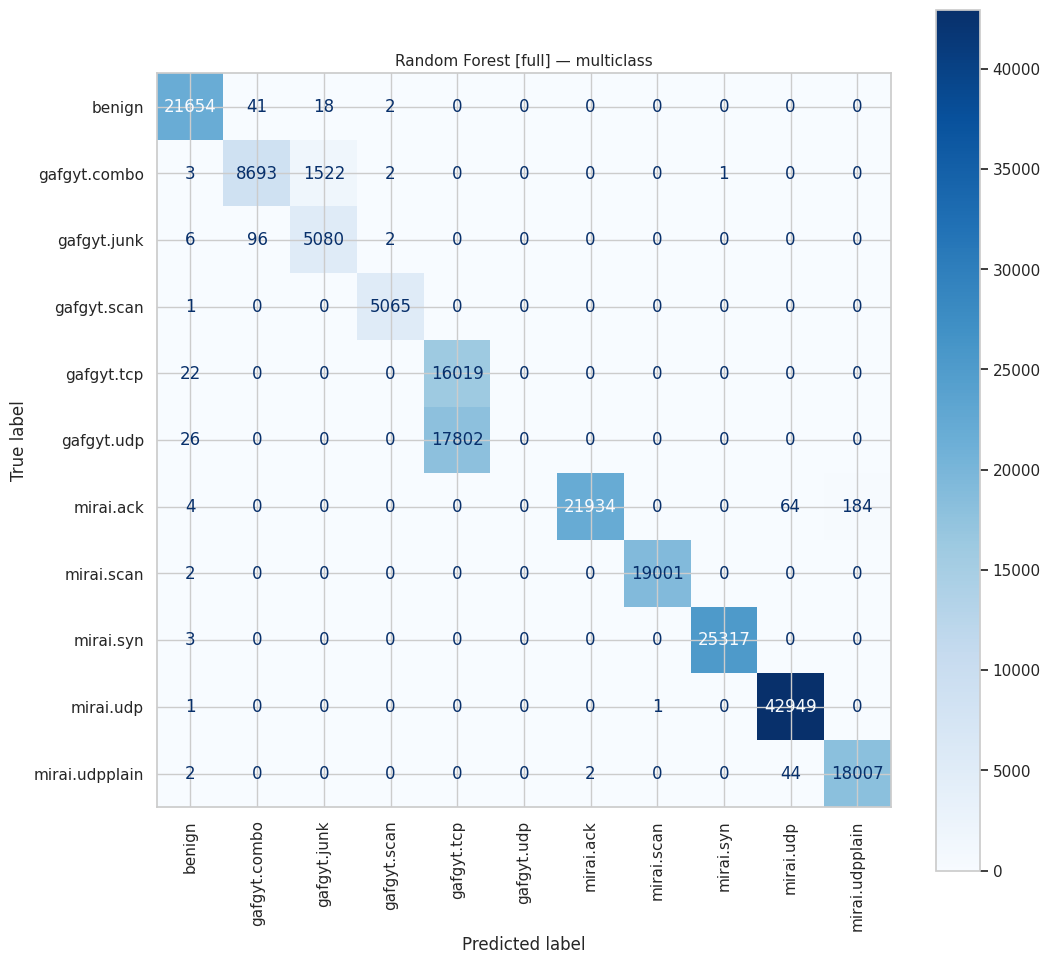

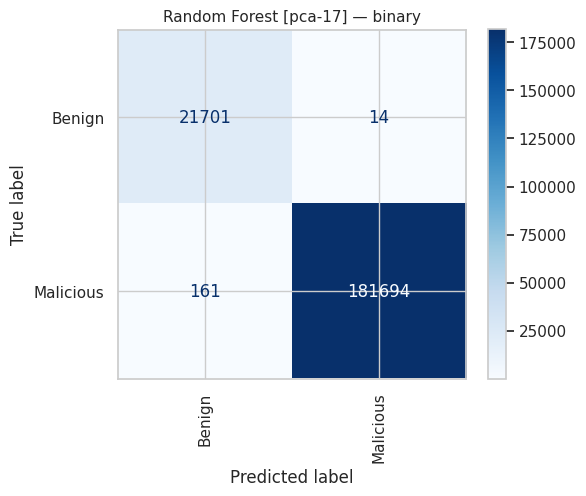

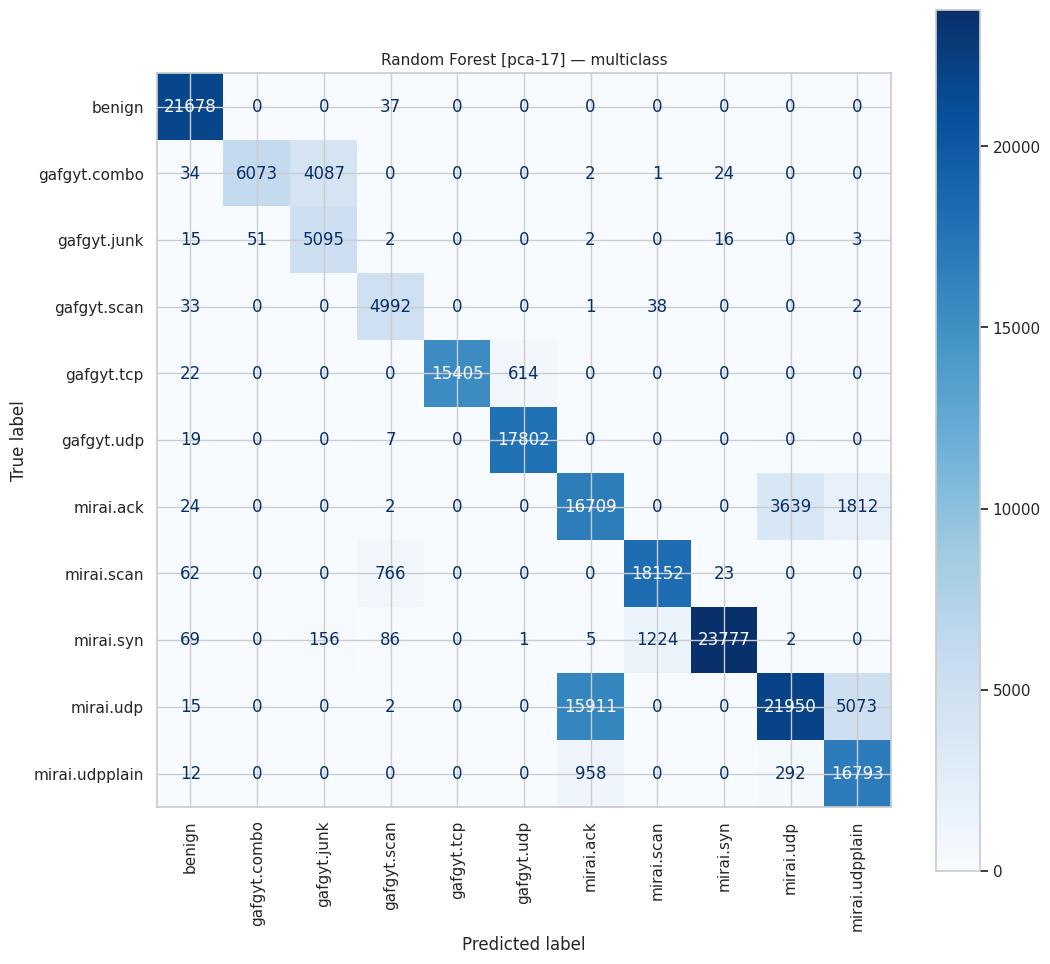

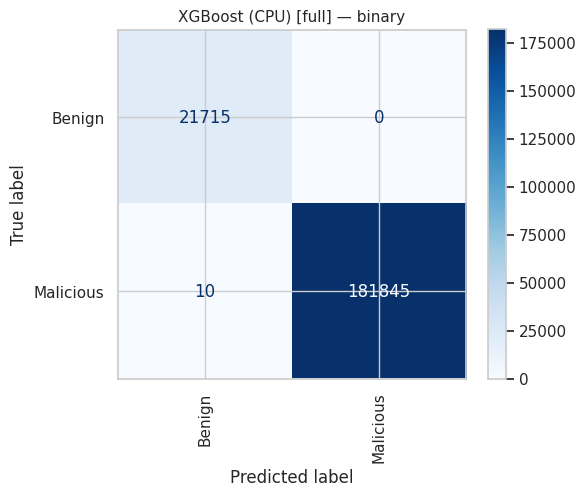

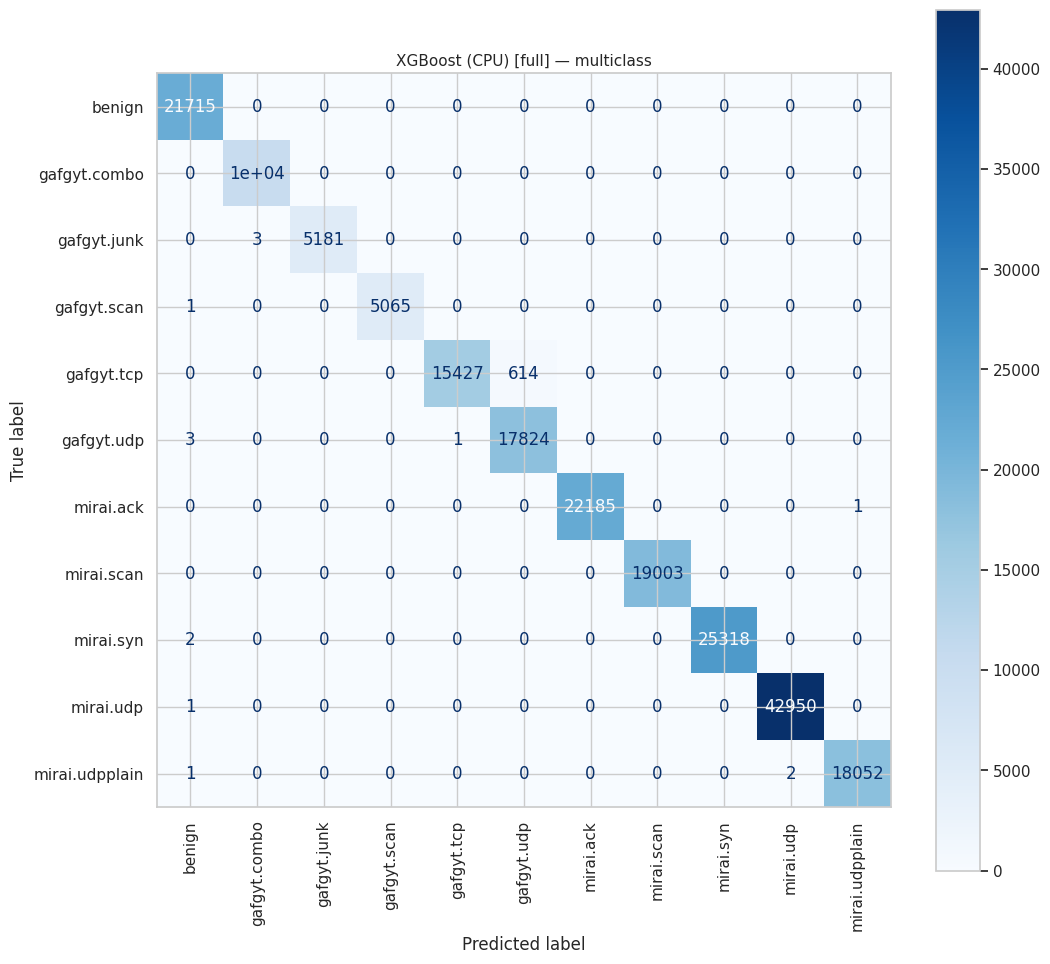

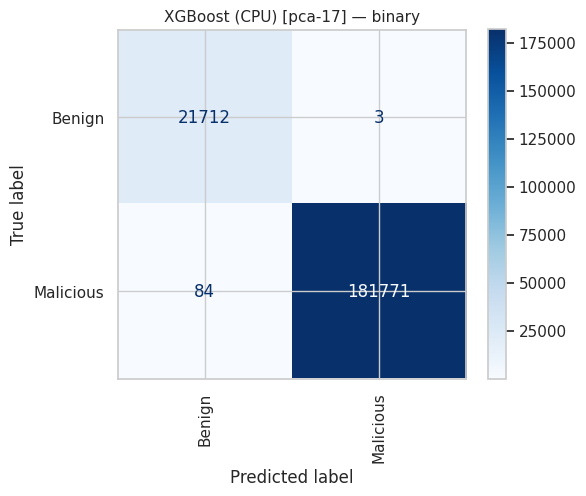

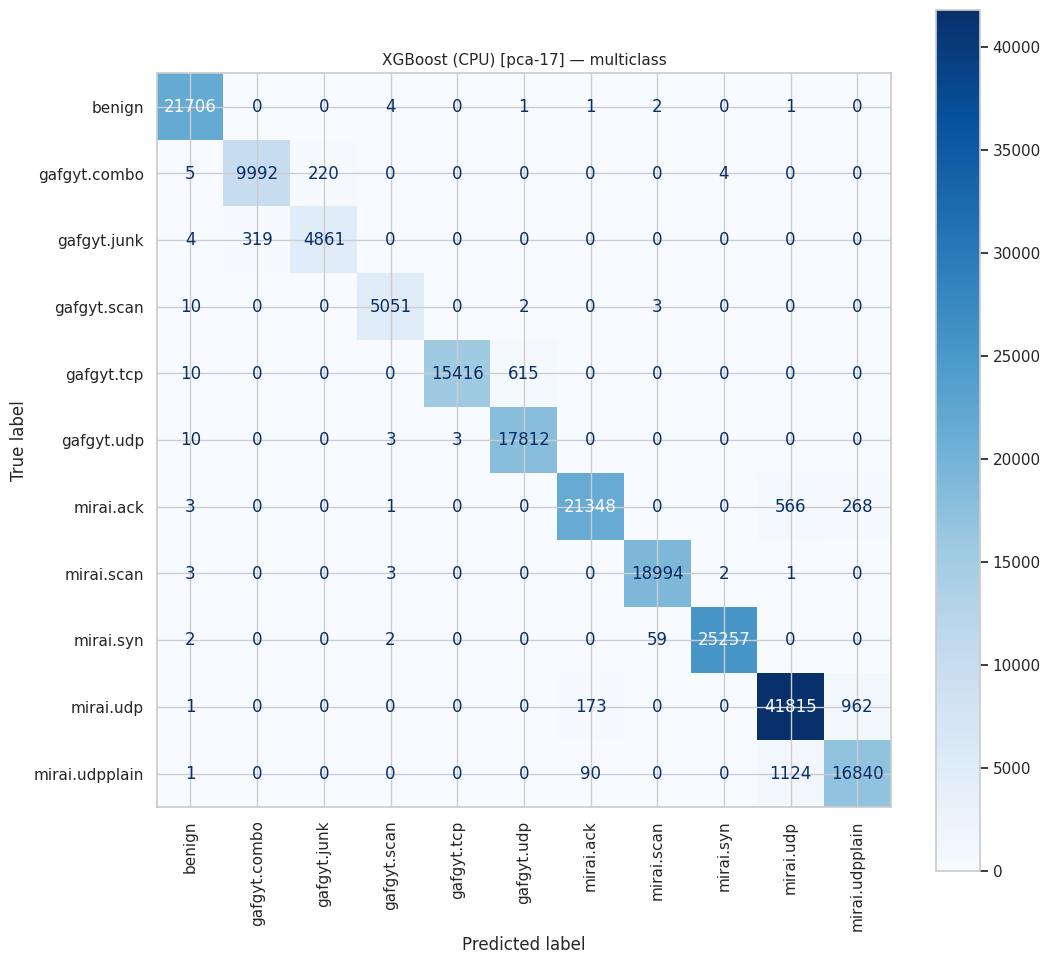

In [21]:
# Получаем тестовые метки из DATASETS
y_test_by_task = {
    task: list(DATASETS.values())[0][task][3]   # y_test — 4-й элемент кортежа
    for task in ["binary", "multiclass"]
}

for algo_name, modes in all_results.items():
    for feature_mode, tasks in modes.items():
        for task, res in tasks.items():

            plot_confusion_matrix(
                y_true      = y_test_by_task[task],
                y_pred      = res["y_pred"],
                class_names = CLASS_NAMES[task],
                title       = f"{algo_name} [{feature_mode}] — {task}"
            )

## 13. Важность признаков

Отображается для всех алгоритмов, у которых есть `feature_importances_`.  
Строится только для режима **full features** (исходные признаки), чтобы сохранить интерпретируемость.

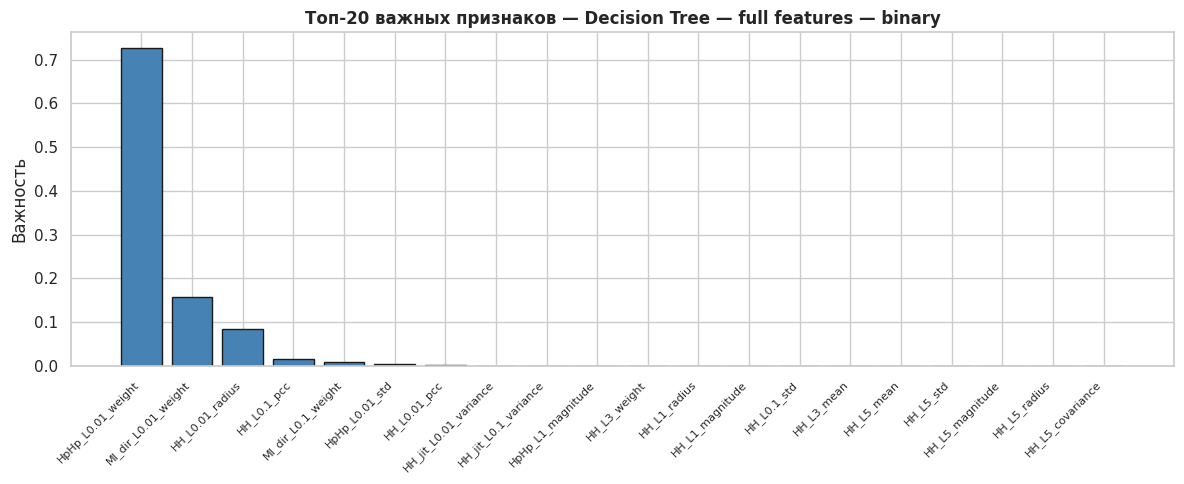

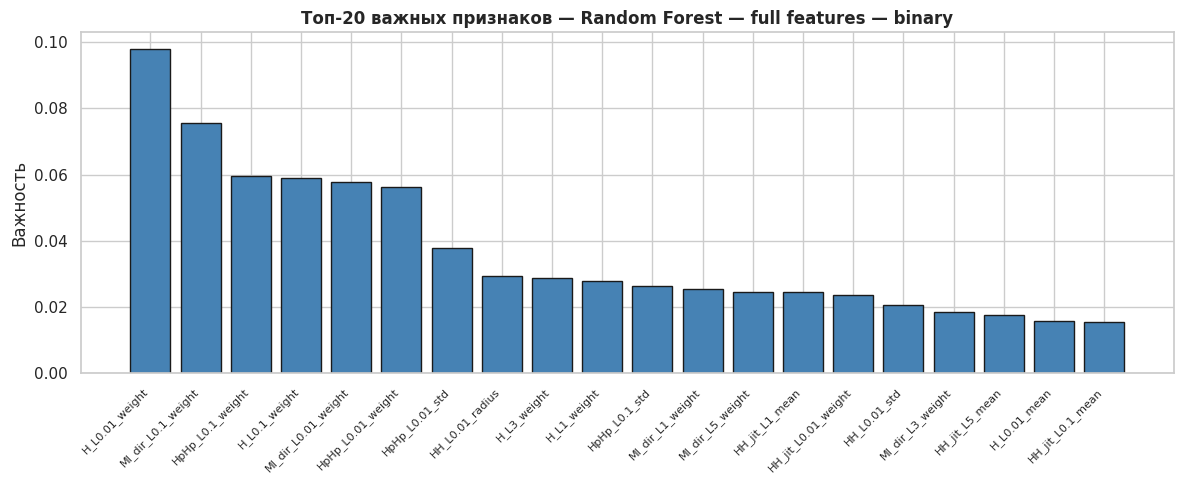

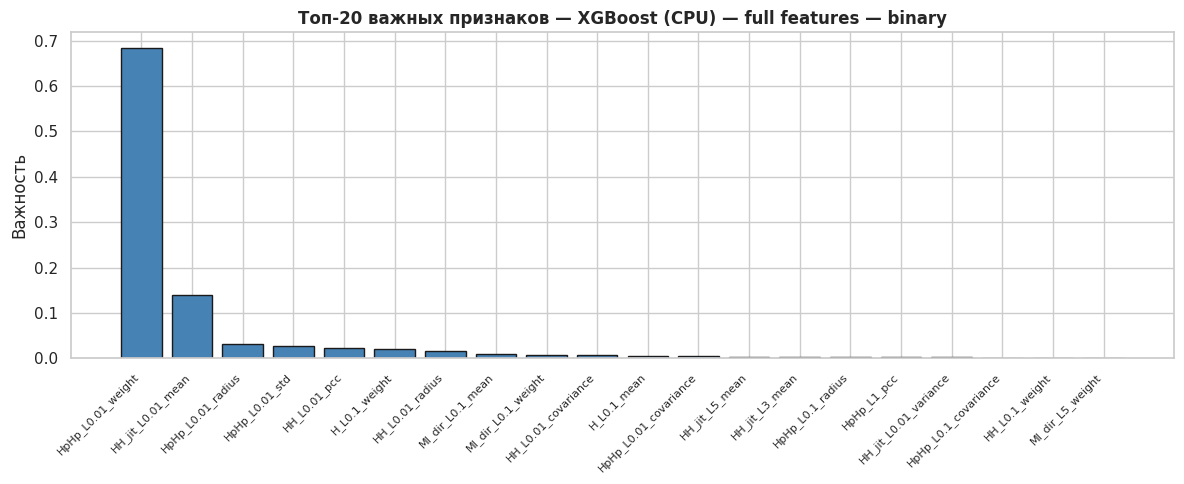

In [23]:
for algo_name, modes in all_results.items():
    # Берём модель, обученную на полных признаках, для бинарной задачи
    trained_model = modes.get("full", {}).get("binary", {}).get("model")

    if trained_model is None:
        continue

    plot_feature_importance(
        model        = trained_model,
        feature_names = FEATURE_COLS,
        title        = f"{algo_name} — full features — binary",
        top_n        = 20,
    )

## 14. Финальный отчёт

In [24]:
print("=" * 72)
print("  ФИНАЛЬНЫЙ ОТЧЁТ")
print("=" * 72)
print(f"  Датасет        : {SAMPLE_FRACTION*100:.0f}% от исходного ({sampled_rows:,} строк)")
print(f"  Train/Test     : {(1-TEST_SIZE)*100:.0f}% / {TEST_SIZE*100:.0f}%")
print(f"  PCA компонент  : {N_PCA_COMPONENTS} (объясн. дисп.: {explained*100:.1f}%)")
print(f"  Алгоритмов     : {len(MODELS)}: {', '.join(MODELS.keys())}")

print("\n── БИНАРНАЯ КЛАССИФИКАЦИЯ ──────────────────────────────────")
print(df_binary.to_string(index=False, float_format="{:.4f}".format))

print("\n── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ───────────────────────────")
print(df_multiclass.to_string(index=False, float_format="{:.4f}".format))

# Ускорение PCA по задаче binary
print("\n── Ускорение обучения от PCA (full / pca) — бинарная ───────")
pca_mode = f"pca-{N_PCA_COMPONENTS}"
for algo_name in MODELS:
    row_full = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]=="full")]
    row_pca  = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]==pca_mode)]
    if row_full.empty or row_pca.empty:
        continue
    t_full  = row_full["Train time (s)"].values[0]
    t_pca   = row_pca["Train time (s)"].values[0]
    speedup = t_full / t_pca if t_pca > 0 else float("inf")
    delta_acc = (row_pca["Accuracy"].values[0] - row_full["Accuracy"].values[0]) * 100
    sign      = "+" if delta_acc >= 0 else ""
    print(f"  {algo_name:<22}: {t_full:6.2f}с → {t_pca:6.2f}с  "
          f"(x{speedup:.1f} быстрее)  ΔAccuracy={sign}{delta_acc:.2f}pp")

  ФИНАЛЬНЫЙ ОТЧЁТ
  Датасет        : 20% от исходного (1,412,521 строк)
  Train/Test     : 80% / 20%
  PCA компонент  : 17 (объясн. дисп.: 95.1%)
  Алгоритмов     : 3: Decision Tree, Random Forest, XGBoost (CPU)

── БИНАРНАЯ КЛАССИФИКАЦИЯ ──────────────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9986     0.9986  0.9998         57.8976
Decision Tree   pca-17    0.9986     1.0000  0.9984         17.2699
Random Forest     full    0.9998     1.0000  0.9997         48.2660
Random Forest   pca-17    0.9991     0.9999  0.9991         51.2424
XGBoost (CPU)     full    1.0000     1.0000  0.9999          7.6774
XGBoost (CPU)   pca-17    0.9996     1.0000  0.9995          2.2578

── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ───────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.8168     0.8582  0.8168         55.3977
Decision Tree   pca-17    0.7293     0.8637  0.7293 